In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/train_transactions.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(5000, 2)
['transaction_text', 'category']


,transaction_text,category
0,Uber ride INR 48648 TXNde8842f7,travel
1,Flipkart order INR 14678 TXN17584829,shopping
2,Home loan EMI INR 44398 TXN8962c016,emi
3,Netflix subscription INR 38748 TXNdce4ee96,entertainment
4,Hospital bill INR 2002 TXNb7e25951,healthcare


In [2]:
df = df.rename(columns={"transaction_text": "description"})
df = df[["description", "category"]].dropna()
print("before dedupe:", df.shape)
df = df.drop_duplicates(subset="description")
print("after dedupe:", df.shape)

print(df.category.value_counts())

first = df.description.str.split().str[0].str.upper()
print("\n", first.nunique(), "distinct first tokens")
print(pd.crosstab(first, df.category).head(20))

before dedupe: (5000, 2)
after dedupe: (5000, 2)
category
education        602
healthcare       570
travel           565
entertainment    557
utilities        554
shopping         546
emi              541
food             534
investment       531
Name: count, dtype: int64

 44 distinct first tokens
category     education  emi  entertainment  food  healthcare  investment  \
description                                                                
AMAZON               0    0              0     0           0           0   
BIKE                 0  120              0     0           0           0   
BUS                  0    0              0     0           0           0   
CAFE                 0    0              0    65           0           0   
CAR                  0  100              0     0           0           0   
CLOTHING             0    0              0     0           0           0   
COLLEGE            166    0              0     0           0           0   
CONCERT         

In [3]:
import re

tmpl = (df.description
          .str.replace(r"INR \d+", "INR <AMT>", regex=True)
          .str.replace(r"TXN\w+", "TXN<REF>", regex=True))

print(tmpl.nunique(), "distinct templates across", len(df), "rows")
print(tmpl.value_counts().head(10))

45 distinct templates across 5000 rows
description
College fees payment INR <AMT> TXN<REF>          166
Movie ticket booking INR <AMT> TXN<REF>          162
Medical test charges INR <AMT> TXN<REF>          153
Pharmacy medicine purchase INR <AMT> TXN<REF>    150
Library fee INR <AMT> TXN<REF>                   148
Online course subscription INR <AMT> TXN<REF>    145
Exam fee INR <AMT> TXN<REF>                      143
Netflix subscription INR <AMT> TXN<REF>          137
Hospital bill INR <AMT> TXN<REF>                 137
Doctor consultation INR <AMT> TXN<REF>           130
Name: count, dtype: int64


In [5]:
train, test = train_test_split(
    df, test_size=0.25, stratify=df.category, random_state=42
)
print(len(train), len(test))

3750 1250


In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

RULES = [
    ("EMI",         "emi"),
    ("LOAN",        "emi"),
    ("CREDIT CARD", "emi"),
    ("HOSPITAL",    "healthcare"),
    ("DOCTOR",      "healthcare"),
    ("PHARMACY",    "healthcare"),
    ("MEDICAL",     "healthcare"),
    ("COLLEGE",     "education"),
    ("EXAM",        "education"),
    ("TUITION",     "education"),
    ("COURSE",      "education"),
    ("FLIGHT",      "travel"),
    ("UBER",        "travel"),
    ("TRAIN",       "travel"),
    ("HOTEL",       "travel"),
    ("NETFLIX",     "entertainment"),
    ("MOVIE",       "entertainment"),
    ("CONCERT",     "entertainment"),
    ("ELECTRICITY", "utilities"),
    ("BROADBAND",   "utilities"),
    ("WATER BILL",  "utilities"),
    ("AMAZON",      "shopping"),
    ("FLIPKART",    "shopping"),
    ("CLOTHING",    "shopping"),
    ("SWIGGY",      "food"),
    ("ZOMATO",      "food"),
    ("RESTAURANT",  "food"),
    ("MUTUAL FUND", "investment"),
    ("CRYPTO",      "investment"),
    ("SIP",         "investment"),
]

MAJORITY = train.category.value_counts().idxmax()

def rule_predict(text):
    t = text.upper()
    for kw, cat in RULES:
        if kw in t:
            return cat
    return MAJORITY

def score(y_true, y_pred, label):
    print(f"--- {label} ---")
    print("accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("macro-F1 :", round(f1_score(y_true, y_pred, average='macro'), 4))
    print(classification_report(y_true, y_pred, zero_division=0))

rules_pred = test.description.apply(rule_predict)
score(test.category, rules_pred, "rules, clean data")

fired = test.description.apply(lambda t: any(kw in t.upper() for kw, _ in RULES))
print("rule coverage:", round(fired.mean(), 3))

--- rules, clean data ---
accuracy : 0.7048
macro-F1 : 0.7333
               precision    recall  f1-score   support

    education       0.30      1.00      0.46       150
          emi       1.00      1.00      1.00       135
entertainment       1.00      0.76      0.87       139
         food       1.00      0.47      0.64       133
   healthcare       1.00      1.00      1.00       143
   investment       1.00      0.42      0.59       133
     shopping       1.00      0.58      0.73       137
       travel       0.87      0.70      0.77       141
    utilities       1.00      0.37      0.54       139

     accuracy                           0.70      1250
    macro avg       0.91      0.70      0.73      1250
 weighted avg       0.90      0.70      0.73      1250

rule coverage: 0.688


In [7]:
print(pd.crosstab(fired, test.category).loc[False])

category
education        36
emi               0
entertainment    33
food             56
healthcare        0
investment       77
shopping         58
travel           43
utilities        87
Name: False, dtype: int64


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), min_df=2),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

model.fit(train.description, train.category)
model_pred = model.predict(test.description)
score(test.category, model_pred, "model, clean data")


--- model, clean data ---
accuracy : 1.0
macro-F1 : 1.0
               precision    recall  f1-score   support

    education       1.00      1.00      1.00       150
          emi       1.00      1.00      1.00       135
entertainment       1.00      1.00      1.00       139
         food       1.00      1.00      1.00       133
   healthcare       1.00      1.00      1.00       143
   investment       1.00      1.00      1.00       133
     shopping       1.00      1.00      1.00       137
       travel       1.00      1.00      1.00       141
    utilities       1.00      1.00      1.00       139

     accuracy                           1.00      1250
    macro avg       1.00      1.00      1.00      1250
 weighted avg       1.00      1.00      1.00      1250



In [9]:
import random

NOISE = ["POS", "PMT", "ACH", "DEB", "CRD", "XX"]

def corrupt(text, severity, rng):
    """Degrade a clean narration toward real bank-statement text.
    severity: 0.0 (untouched) to 1.0 (heavily mangled)."""
    t = text.upper()

    # 1. abbreviation — banks drop vowels to fit field widths
    words = []
    for w in t.split():
        if len(w) > 4 and rng.random() < severity:
            w = w[0] + "".join(c for c in w[1:] if c not in "AEIOU")
        words.append(w)
    t = " ".join(words)

    # 2. processor noise tokens bolted on either end
    if rng.random() < severity:
        t = rng.choice(NOISE) + " " + t
    if rng.random() < severity:
        t = t + " " + rng.choice(NOISE) + str(rng.randint(100, 999))

    # 3. lost delimiters
    if rng.random() < severity * 0.6:
        t = t.replace(" ", "")

    # 4. character-level corruption
    t = "".join(c for c in t if rng.random() > severity * 0.08)

    # 5. truncation to a fixed field width
    if rng.random() < severity:
        t = t[:22]

    return t


rng = random.Random(0)
sample = df.description.sample(4, random_state=7).tolist()
for s in sample:
    print(repr(s))
    for sev in [0.25, 0.5, 0.75, 1.0]:
        print(f"   {sev:>4}  {corrupt(s, sev, rng)!r}")
    print()

'Medical test charges INR 42905 TXN67a07fa2'
   0.25  'MEDICAL TEST CHARGES INR 4295 TX67A07FA2'
    0.5  'MEDICALTESTCHRGSINR42905TXN6707F2'
   0.75  'MDCLTESTCHRGSIR4295TXN677FA2'
    1.0  'MTMDCLTESTCHRGSINR4905'

'Movie ticket booking INR 41858 TXNf4943a48'
   0.25  'MOVIE TICKET BKNG NR 41858 TXN49A48 CRD296'
    0.5  'ACHMOVIE TICKET BKNGIN'
   0.75  'MV TCT BKNG INR 41858 TXNF443A48 DEB925'
    1.0  'PMTVTCKTBKGIR858TXNF49'

'Home loan EMI INR 8427 TXNcd757b8f'
   0.25  'HOM LOAN EMI INR 8427 TXNCD757B8F'
    0.5  'CRDHOMELOANEMIINR8427XNCD7578'
   0.75  'HOME LOAN EMI INR 8427'
    1.0  'POSHOMELOANEMIINR4XNCD'

'Electronics shopping INR 26152 TXNb10047a7'
   0.25  'ELECTRONICS HOPING INR'
    0.5  'PMT ELECTRONICS SHPPNG'
   0.75  'XXELCTRNCSSPPNGINR2615'
    1.0  'PMTELRNCSSHPPNGIN215TX'



In [11]:
import random

NOISE = ["POS", "PMT", "ACH", "DEB", "CRD", "XX"]

def corrupt(text, severity, rng):
    """Degrade a clean narration toward real bank-statement text.
    severity: 0.0 (untouched) to 1.0 (heavily mangled)."""
    t = text.upper()

    # 1. abbreviation — banks drop vowels to fit field widths
    words = []
    for w in t.split():
        if len(w) > 4 and rng.random() < severity:
            w = w[0] + "".join(c for c in w[1:] if c not in "AEIOU")
        words.append(w)
    t = " ".join(words)

    # 2. processor noise tokens bolted on either end
    if rng.random() < severity:
        t = rng.choice(NOISE) + " " + t
    if rng.random() < severity:
        t = t + " " + rng.choice(NOISE) + str(rng.randint(100, 999))

    # 3. lost delimiters
    if rng.random() < severity * 0.6:
        t = t.replace(" ", "")

    # 4. character-level corruption
    t = "".join(c for c in t if rng.random() > severity * 0.08)

    # 5. truncation to a fixed field width — narrows with severity
    width = int(40 - 20 * severity)
    t = t[:width]

    return t


rng = random.Random(0)
sample = df.description.sample(4, random_state=7).tolist()
for s in sample:
    print(repr(s))
    for sev in [0.25, 0.5, 0.75, 1.0]:
        print(f"   {sev:>4}  {corrupt(s, sev, rng)!r}")
    print()

'Medical test charges INR 42905 TXN67a07fa2'
   0.25  'MEDICAL TEST CHARGES INR 4295 TX67A'
    0.5  'CRD MEDICAL TES CHARGS INR 429'
   0.75  'ACHMCLTETCHRGSR42905XN670'
    1.0  'XX MDCL TST CHRGS IR'

'Movie ticket booking INR 41858 TXNf4943a48'
   0.25  'X MOVIE TICKE BKING INR 41858 TXNF4'
    0.5  'CRDMOVETICKETBKNGINR41858TXNF4'
   0.75  'MV TCKT BKG INR 41858 TXN'
    1.0  'OS MV TKTBG INR 4185'

'Home loan EMI INR 8427 TXNcd757b8f'
   0.25  'HOMELOANEMIINR8427TXNCD757B8F'
    0.5  'DEB HOME LOAN EMI IR 8427 XCD7'
   0.75  'POS HMELOAN EIINR 8427 XC'
    1.0  'CRD HOEAN EMI INR842'

'Electronics shopping INR 26152 TXNb10047a7'
   0.25  'ELECTRONICS SHPPNG INR 26152 TXNB10'
    0.5  'ELECTRONIS HPPNG NR 26152 TXNB'
   0.75  'DEB ELCTRNC SHPPNG IN2652'
    1.0  'E ECTRNCS SHPNG NR 2'



In [12]:
SEVERITIES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
results = []

for sev in SEVERITIES:
    r_test  = random.Random(100)
    r_train = random.Random(200)

    test_c  = test.description.apply(lambda t: corrupt(t, sev, r_test))
    train_c = train.description.apply(lambda t: corrupt(t, sev, r_train))

    # 1. rules — fixed system, never retrained
    f1_rules = f1_score(test.category, test_c.apply(rule_predict), average='macro')

    # 2. model trained on clean data, meeting corrupted input
    f1_clean = f1_score(test.category, model.predict(test_c), average='macro')

    # 3. model retrained on equally corrupted data
    m2 = make_pipeline(
        TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), min_df=2),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    )
    m2.fit(train_c, train.category)
    f1_retrain = f1_score(test.category, m2.predict(test_c), average='macro')

    results.append({
        "severity": sev,
        "rules": round(f1_rules, 4),
        "model_trained_clean": round(f1_clean, 4),
        "model_retrained": round(f1_retrain, 4),
    })
    print(results[-1])

res = pd.DataFrame(results)
res

{'severity': 0.0, 'rules': 0.7333, 'model_trained_clean': 1.0, 'model_retrained': 1.0}
{'severity': 0.2, 'rules': 0.6245, 'model_trained_clean': 0.9768, 'model_retrained': 0.9992}
{'severity': 0.4, 'rules': 0.4966, 'model_trained_clean': 0.9384, 'model_retrained': 0.9984}
{'severity': 0.6, 'rules': 0.4029, 'model_trained_clean': 0.887, 'model_retrained': 0.996}
{'severity': 0.8, 'rules': 0.316, 'model_trained_clean': 0.8416, 'model_retrained': 0.9959}
{'severity': 1.0, 'rules': 0.1848, 'model_trained_clean': 0.7515, 'model_retrained': 0.9968}


,severity,rules,model_trained_clean,model_retrained
0,0.0,0.7333,1.0000,1.0000
1,0.2,0.6245,0.9768,0.9992
2,0.4,0.4966,0.9384,0.9984
3,0.6,0.4029,0.8870,0.9960
4,0.8,0.3160,0.8416,0.9959
5,1.0,0.1848,0.7515,0.9968


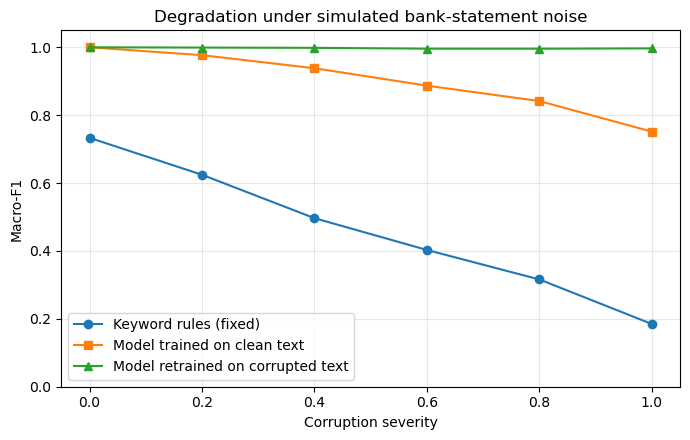

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(res.severity, res.rules, marker='o', label='Keyword rules (fixed)')
ax.plot(res.severity, res.model_trained_clean, marker='s', label='Model trained on clean text')
ax.plot(res.severity, res.model_retrained, marker='^', label='Model retrained on corrupted text')

ax.set_xlabel("Corruption severity")
ax.set_ylabel("Macro-F1")
ax.set_title("Degradation under simulated bank-statement noise")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("degradation.png", dpi=150)
plt.show()